# Synthetic Raster-to-Vector: Threshold vs MLP vs Small CNN

**Results for this were disapointing as threshold was already good so all outputs had the same results**

This notebook compares three pixel classifiers for detecting vector-stroke pixels:

1. **Threshold baseline**: `pixel <= 0.5 -> dot`
2. **MLP pixel classifier**: predicts a stroke pixel from a small local patch
3. **Small CNN segmenter**: predicts a full stroke mask from the image

The vector reconstruction stage is then reused to convert pixel masks into explicit line segments.

In [1]:

# Optional install if running in a new environment:
# !pip install torch torchvision matplotlib pillow numpy pandas

import math
import random
from dataclasses import dataclass
from collections import defaultdict, deque
from pathlib import Path
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

torch.set_num_threads(1)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEVICE)


Using device: cpu


In [2]:

# -----------------------------
# Configuration
# -----------------------------
IMG_SIZE = 128
MAX_LINES = 5
LINE_WIDTH = 1

N_TRAIN = 80
N_TEST = 20

# None = different synthetic data every full notebook run.
# Set an integer such as 42 if you need repeatable results.
SEED = None

BLACK = 0
WHITE = 255
THRESHOLD_BLACKNESS = 0.50

# Add mild greyscale noise so the ML classifiers are doing more than copying a perfect threshold.
# Set to 0.0 for perfectly clean black-on-white rasters.
NOISE_STD = 12.0

# Minimum predicted vector length.
# 2.0 means at least 3 pixel positions; avoids 2-adjacent-pixel fragments.
MIN_LINE_LENGTH = 2.0

# Junction cleanup settings.
JUNCTION_SNAP_RADIUS = 3.0
JUNCTION_INTERNAL_FRAGMENT_LENGTH = 4.0

# Safe merge controls.
MAX_MERGE_COMPARISONS = 5000
MERGE_DIAGNOSTICS = False

# Training controls.
MLP_EPOCHS = 4
CNN_EPOCHS = 2
BATCH_SIZE = 16
MLP_PIXELS_PER_IMAGE = 256

if SEED is not None:
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)


## 1. Synthetic vector data

In [3]:

@dataclass
class VectorLine:
    x1: float
    y1: float
    x2: float
    y2: float

    def as_tuple(self):
        return (self.x1, self.y1, self.x2, self.y2)


def random_line(img_size=128, min_length=8):
    while True:
        x1 = random.randint(2, img_size - 3)
        y1 = random.randint(2, img_size - 3)
        x2 = random.randint(2, img_size - 3)
        y2 = random.randint(2, img_size - 3)
        length = math.hypot(x2 - x1, y2 - y1)
        if length >= min_length:
            return VectorLine(x1, y1, x2, y2)


def generate_vector_sample(max_lines=5, img_size=128):
    n_lines = random.randint(1, max_lines)
    return [random_line(img_size=img_size) for _ in range(n_lines)]


def rasterise_vectors(lines, img_size=128, line_width=1):
    image = Image.new('L', (img_size, img_size), WHITE)
    draw = ImageDraw.Draw(image)
    for line in lines:
        draw.line((line.x1, line.y1, line.x2, line.y2), fill=BLACK, width=line_width)
    return np.array(image, dtype=np.uint8)


def add_image_noise(raster, noise_std=NOISE_STD):
    if noise_std <= 0:
        return raster.copy()
    noisy = raster.astype(np.float32) + np.random.normal(0, noise_std, raster.shape)
    return np.clip(noisy, 0, 255).astype(np.uint8)


def make_dataset(n_samples):
    vectors = []
    clean = []
    noisy = []
    masks = []
    for _ in range(n_samples):
        lines = generate_vector_sample(MAX_LINES, IMG_SIZE)
        raster = rasterise_vectors(lines, IMG_SIZE, LINE_WIDTH)
        mask = (raster < 128).astype(np.float32)
        vectors.append(lines)
        clean.append(raster)
        noisy.append(add_image_noise(raster))
        masks.append(mask)
    return vectors, np.stack(clean), np.stack(noisy), np.stack(masks)

train_vectors, train_clean, train_images, train_masks = make_dataset(N_TRAIN)
test_vectors, test_clean, test_images, test_masks = make_dataset(N_TEST)

print('Train images:', train_images.shape)
print('Test images:', test_images.shape)


Train images: (80, 128, 128)
Test images: (20, 128, 128)


## 2. Pixel classifiers

In [4]:

def threshold_predict_mask(raster, blackness_threshold=THRESHOLD_BLACKNESS):
    blackness = 1.0 - raster.astype(np.float32) / 255.0
    return blackness >= blackness_threshold


class MLPPixelClassifier(nn.Module):
    def __init__(self, patch_size=5, hidden=64):
        super().__init__()
        self.patch_size = patch_size
        self.net = nn.Sequential(
            nn.Linear(patch_size * patch_size, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


class SmallCNNSegmenter(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(8, 8, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(8, 1, 1),
        )

    def forward(self, x):
        return self.net(x)


## 3. Train MLP pixel classifier

In [5]:

def sample_pixel_patches(images, masks, patch_size=5, pixels_per_image=256):
    """Fast patch sampler. Samples only the pixels we need instead of unfolding every image."""
    pad = patch_size // 2
    X_parts = []
    y_parts = []
    for img, mask in zip(images, masks):
        img01 = img.astype(np.float32) / 255.0
        padded = np.pad(img01, pad, mode='reflect')
        labels_flat = mask.reshape(-1)
        pos_idx = np.where(labels_flat > 0.5)[0]
        neg_idx = np.where(labels_flat <= 0.5)[0]

        n_pos = min(len(pos_idx), pixels_per_image // 2)
        n_neg = pixels_per_image - n_pos
        if n_pos > 0:
            chosen_pos = np.random.choice(pos_idx, n_pos, replace=True)
        else:
            chosen_pos = np.array([], dtype=np.int64)
        chosen_neg = np.random.choice(neg_idx, n_neg, replace=True)
        chosen = np.concatenate([chosen_pos, chosen_neg])
        np.random.shuffle(chosen)

        ys = chosen // IMG_SIZE
        xs = chosen % IMG_SIZE
        patches = np.empty((len(chosen), patch_size * patch_size), dtype=np.float32)
        for j, (x, y) in enumerate(zip(xs, ys)):
            patch = padded[y:y+patch_size, x:x+patch_size]
            patches[j] = patch.reshape(-1)
        X_parts.append(patches)
        y_parts.append(labels_flat[chosen].astype(np.float32))

    X = torch.tensor(np.concatenate(X_parts, axis=0), dtype=torch.float32)
    y = torch.tensor(np.concatenate(y_parts, axis=0), dtype=torch.float32)
    return X, y

mlp_X, mlp_y = sample_pixel_patches(train_images, train_masks, patch_size=5, pixels_per_image=MLP_PIXELS_PER_IMAGE)
mlp_loader = DataLoader(TensorDataset(mlp_X, mlp_y), batch_size=4096, shuffle=True)

mlp_model = MLPPixelClassifier(patch_size=5).to(DEVICE)
mlp_opt = torch.optim.Adam(mlp_model.parameters(), lr=1e-3)

for epoch in range(MLP_EPOCHS):
    mlp_model.train()
    total_loss = 0.0
    for xb, yb in mlp_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = mlp_model(xb)
        loss = F.binary_cross_entropy_with_logits(logits, yb)
        mlp_opt.zero_grad()
        loss.backward()
        mlp_opt.step()
        total_loss += loss.item() * len(xb)
    print(f'MLP epoch {epoch+1}/{MLP_EPOCHS} loss: {total_loss / len(mlp_X):.4f}')


MLP epoch 1/4 loss: 0.6786
MLP epoch 2/4 loss: 0.6488
MLP epoch 3/4 loss: 0.6287
MLP epoch 4/4 loss: 0.6103


In [6]:

@torch.no_grad()
def mlp_predict_mask(raster, threshold=0.30, patch_size=5, batch_size=65536):
    mlp_model.eval()
    pad = patch_size // 2
    img01 = torch.tensor(raster / 255.0, dtype=torch.float32)[None, None]
    padded = F.pad(img01, (pad, pad, pad, pad), mode='reflect')
    patches = F.unfold(padded, kernel_size=patch_size).squeeze(0).T

    probs = []
    for i in range(0, len(patches), batch_size):
        xb = patches[i:i+batch_size].to(DEVICE)
        p = torch.sigmoid(mlp_model(xb)).cpu()
        probs.append(p)
    probs = torch.cat(probs).numpy().reshape(IMG_SIZE, IMG_SIZE)
    return (probs >= threshold) & ((1.0 - raster.astype(np.float32) / 255.0) >= 0.25)


## 4. Train small CNN pixel classifier

In [7]:

class RasterMaskDataset(Dataset):
    def __init__(self, images, masks):
        self.images = images
        self.masks = masks

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        x = torch.tensor(self.images[idx] / 255.0, dtype=torch.float32)[None]
        y = torch.tensor(self.masks[idx], dtype=torch.float32)[None]
        return x, y

cnn_loader = DataLoader(RasterMaskDataset(train_images, train_masks), batch_size=BATCH_SIZE, shuffle=True)
cnn_model = SmallCNNSegmenter().to(DEVICE)
cnn_opt = torch.optim.Adam(cnn_model.parameters(), lr=1e-3)

# Positive pixels are sparse, so use a positive class weight.
pos = train_masks.sum()
neg = train_masks.size - pos
pos_weight = torch.tensor([neg / max(pos, 1)], dtype=torch.float32, device=DEVICE)
print('CNN positive class weight:', float(pos_weight.item()))

for epoch in range(CNN_EPOCHS):
    cnn_model.train()
    total_loss = 0.0
    for xb, yb in cnn_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = cnn_model(xb)
        loss = F.binary_cross_entropy_with_logits(logits, yb, pos_weight=pos_weight)
        cnn_opt.zero_grad()
        loss.backward()
        cnn_opt.step()
        total_loss += loss.item() * len(xb)
    print(f'CNN epoch {epoch+1}/{CNN_EPOCHS} loss: {total_loss / len(cnn_loader.dataset):.4f}')


CNN positive class weight: 90.3330078125
CNN epoch 1/2 loss: 1.4029
CNN epoch 2/2 loss: 1.3875


In [8]:

@torch.no_grad()
def cnn_predict_mask(raster, threshold=0.30):
    cnn_model.eval()
    x = torch.tensor(raster / 255.0, dtype=torch.float32)[None, None].to(DEVICE)
    logits = cnn_model(x)
    probs = torch.sigmoid(logits)[0, 0].cpu().numpy()
    return (probs >= threshold) & ((1.0 - raster.astype(np.float32) / 255.0) >= 0.25)


## 5. Reconstruction utilities

In [9]:
NEIGHBOURS_8 = [
    (-1, -1), (0, -1), (1, -1),
    (-1,  0),          (1,  0),
    (-1,  1), (0,  1), (1,  1),
]


def in_bounds(x, y, img_size=128):
    return 0 <= x < img_size and 0 <= y < img_size


def get_binary_neighbours(binary, x, y):
    h, w = binary.shape
    out = []
    for dx, dy in NEIGHBOURS_8:
        nx, ny = x + dx, y + dy
        if 0 <= nx < w and 0 <= ny < h and binary[ny, nx]:
            out.append((nx, ny))
    return out


def connected_components(binary):
    h, w = binary.shape
    visited = np.zeros_like(binary, dtype=bool)
    components = []

    for y in range(h):
        for x in range(w):
            if not binary[y, x] or visited[y, x]:
                continue

            q = deque([(x, y)])
            visited[y, x] = True
            comp = []

            while q:
                px, py = q.popleft()
                comp.append((px, py))
                for nx, ny in get_binary_neighbours(binary, px, py):
                    if not visited[ny, nx]:
                        visited[ny, nx] = True
                        q.append((nx, ny))

            components.append(comp)

    return components


def dot_coordinates(binary):
    ys, xs = np.where(binary)
    return list(zip(xs.tolist(), ys.tolist()))


In [10]:
def pixel_degree(binary, x, y):
    return len(get_binary_neighbours(binary, x, y))


def classify_graph_pixels(binary):
    endpoints = set()
    junctions = set()
    normal = set()

    ys, xs = np.where(binary)
    for x, y in zip(xs, ys):
        deg = pixel_degree(binary, x, y)
        if deg <= 1:
            endpoints.add((x, y))
        elif deg >= 3:
            junctions.add((x, y))
        else:
            normal.add((x, y))
    return endpoints, junctions, normal


def cluster_special_pixels(points, max_dist=1.5):
    """Fast bounded clustering for endpoint/junction pixels.

    The earlier version compared every point with every other point.
    This version uses a grid lookup, so it does not hang when many junction
    pixels are close together.
    """
    points = set(points)
    clusters = []

    while points:
        start = points.pop()
        q = deque([start])
        cluster = [start]

        while q:
            px, py = q.popleft()
            nearby = []

            # Only inspect a tiny local window instead of scanning all points.
            r = int(math.ceil(max_dist))
            for ny in range(py - r, py + r + 1):
                for nx in range(px - r, px + r + 1):
                    p = (nx, ny)
                    if p in points and math.hypot(nx - px, ny - py) <= max_dist:
                        nearby.append(p)

            for p in nearby:
                points.remove(p)
                q.append(p)
                cluster.append(p)

        clusters.append(cluster)

    return clusters


def cluster_centres(clusters):
    centres = []
    for cluster in clusters:
        xs = [p[0] for p in cluster]
        ys = [p[1] for p in cluster]
        centres.append((float(np.mean(xs)), float(np.mean(ys))))
    return centres


In [11]:
def trace_branches(binary):
    endpoints, junctions, normal = classify_graph_pixels(binary)
    special = endpoints | junctions
    pixels = set(dot_coordinates(binary))

    visited_edges = set()
    branches = []

    def edge_key(a, b):
        return tuple(sorted([a, b]))

    # Trace from every special pixel outward.
    for start in list(special):
        for nxt in get_binary_neighbours(binary, *start):
            ek = edge_key(start, nxt)
            if ek in visited_edges:
                continue

            path = [start, nxt]
            visited_edges.add(ek)
            prev = start
            cur = nxt

            while cur not in special:
                neigh = get_binary_neighbours(binary, *cur)
                candidates = [p for p in neigh if p != prev]
                if not candidates:
                    break

                # Prefer unvisited edge. This prevents immediate loops.
                unvisited = [p for p in candidates if edge_key(cur, p) not in visited_edges]
                if not unvisited:
                    break

                # Continue in the smoothest direction.
                vx, vy = cur[0] - prev[0], cur[1] - prev[1]
                def turn_score(p):
                    wx, wy = p[0] - cur[0], p[1] - cur[1]
                    return -(vx * wx + vy * wy)

                nxt2 = min(unvisited, key=turn_score)
                visited_edges.add(edge_key(cur, nxt2))
                path.append(nxt2)
                prev, cur = cur, nxt2

            if len(path) >= 2:
                branches.append(path)

    # If there are loops with no special pixels, trace remaining edges.
    for p in pixels:
        for q in get_binary_neighbours(binary, *p):
            if edge_key(p, q) in visited_edges:
                continue
            path = [p, q]
            visited_edges.add(edge_key(p, q))
            branches.append(path)

    return branches, endpoints, junctions


In [12]:
def fit_line_pca(points):
    arr = np.array(points, dtype=np.float32)
    if len(arr) == 1:
        x, y = arr[0]
        return VectorLine(x, y, x, y), 0.0

    mean = arr.mean(axis=0)
    centered = arr - mean
    _, _, vh = np.linalg.svd(centered, full_matrices=False)
    direction = vh[0]

    projections = centered @ direction
    p1 = mean + projections.min() * direction
    p2 = mean + projections.max() * direction

    # perpendicular fit error
    reconstructed = np.outer(projections, direction) + mean
    errors = np.linalg.norm(arr - reconstructed, axis=1)
    mean_error = float(errors.mean())

    return VectorLine(p1[0], p1[1], p2[0], p2[1]), mean_error


def branch_to_vectors(branches, min_branch_pixels=3, max_fit_error=1.5):
    fitted = []
    for branch in branches:
        if len(branch) < min_branch_pixels:
            continue
        line, err = fit_line_pca(branch)
        if err <= max_fit_error:
            fitted.append((line, err, branch))
    return fitted


In [13]:
def line_angle(line):
    return math.atan2(line.y2 - line.y1, line.x2 - line.x1)


def angle_difference(a, b):
    diff = abs(a - b) % math.pi
    return min(diff, math.pi - diff)


def point_line_distance(px, py, line):
    x1, y1, x2, y2 = line.as_tuple()
    dx, dy = x2 - x1, y2 - y1
    denom = math.hypot(dx, dy)
    if denom == 0:
        return math.hypot(px - x1, py - y1)
    return abs(dy * px - dx * py + x2 * y1 - y2 * x1) / denom


def endpoints_close(a, b, threshold=3.0):
    ea = [(a.x1, a.y1), (a.x2, a.y2)]
    eb = [(b.x1, b.y1), (b.x2, b.y2)]
    return min(math.hypot(xa - xb, ya - yb) for xa, ya in ea for xb, yb in eb) <= threshold


def line_length(line):
    return math.hypot(line.x2 - line.x1, line.y2 - line.y1)


def merge_two_lines(a, b):
    pts = [(a.x1, a.y1), (a.x2, a.y2), (b.x1, b.y1), (b.x2, b.y2)]
    merged, _ = fit_line_pca(pts)
    return merged


def line_midpoint(line):
    return ((line.x1 + line.x2) / 2, (line.y1 + line.y2) / 2)


def can_merge_lines(a, b, angle_thresh, distance_thresh, endpoint_thresh):
    if angle_difference(line_angle(a), line_angle(b)) > angle_thresh:
        return False
    if not endpoints_close(a, b, endpoint_thresh):
        return False

    # Both endpoints of b should lie close to the support line of a, and vice versa.
    # The reverse test prevents accidental long merges across junctions.
    return (
        point_line_distance(b.x1, b.y1, a) <= distance_thresh and
        point_line_distance(b.x2, b.y2, a) <= distance_thresh and
        point_line_distance(a.x1, a.y1, b) <= distance_thresh and
        point_line_distance(a.x2, a.y2, b) <= distance_thresh
    )


def merge_collinear_lines(
    lines,
    angle_thresh_deg=8,
    distance_thresh=1.5,
    endpoint_thresh=3.0,
    max_comparisons=MAX_MERGE_COMPARISONS,
    diagnostics=MERGE_DIAGNOSTICS,
):
    """Bounded greedy merge.

    The older version repeatedly compared every line with every other line.
    That can hang when a junction creates many tiny fragments.

    This version:
    - sorts longer lines first;
    - compares each line only with nearby endpoints;
    - allows at most one merge per input line in this pass;
    - stops after max_comparisons comparisons.
    """
    lines = list(lines)
    if len(lines) <= 1:
        return lines

    angle_thresh = math.radians(angle_thresh_deg)

    # Long lines first; short fragments then get absorbed into nearby longer lines.
    order = sorted(range(len(lines)), key=lambda i: line_length(lines[i]), reverse=True)

    # Spatial index based on line endpoints.
    cell_size = max(endpoint_thresh, 1.0)
    grid = defaultdict(set)

    def grid_key(x, y):
        return (int(x // cell_size), int(y // cell_size))

    for i, line in enumerate(lines):
        for x, y in [(line.x1, line.y1), (line.x2, line.y2)]:
            gx, gy = grid_key(x, y)
            for dx in (-1, 0, 1):
                for dy in (-1, 0, 1):
                    grid[(gx + dx, gy + dy)].add(i)

    used = set()
    output = []
    comparisons = 0
    merges = 0
    hit_cap = False

    for i in order:
        if i in used:
            continue

        current = lines[i]
        used.add(i)

        # Candidate lines that have an endpoint near one of current's endpoints.
        candidate_ids = set()
        for x, y in [(current.x1, current.y1), (current.x2, current.y2)]:
            candidate_ids.update(grid[grid_key(x, y)])

        candidate_ids.discard(i)
        candidate_ids = [j for j in candidate_ids if j not in used]
        candidate_ids.sort(key=lambda j: line_length(lines[j]))

        best_j = None
        best_score = float('inf')

        for j in candidate_ids:
            if comparisons >= max_comparisons:
                hit_cap = True
                break

            comparisons += 1
            other = lines[j]

            if can_merge_lines(current, other, angle_thresh, distance_thresh, endpoint_thresh):
                # Prefer the closest endpoint pair.
                score = min(
                    math.hypot(xa - xb, ya - yb)
                    for xa, ya in [(current.x1, current.y1), (current.x2, current.y2)]
                    for xb, yb in [(other.x1, other.y1), (other.x2, other.y2)]
                )
                if score < best_score:
                    best_score = score
                    best_j = j

        if best_j is not None:
            current = merge_two_lines(current, lines[best_j])
            used.add(best_j)
            merges += 1

        output.append(current)

        if hit_cap:
            # Add remaining unprocessed lines unchanged.
            for k in order:
                if k not in used:
                    output.append(lines[k])
                    used.add(k)
            break

    if diagnostics:
        message = f"merge_collinear_lines: input={len(lines)}, output={len(output)}, merges={merges}, comparisons={comparisons}"
        if hit_cap:
            message += "  [stopped at safety cap]"
        print(message)

    return output


In [14]:
def line_length(line):
    return math.hypot(line.x2 - line.x1, line.y2 - line.y1)


def nearest_junction(point, junction_centres, max_dist=JUNCTION_SNAP_RADIUS):
    if not junction_centres:
        return None, None
    px, py = point
    best = None
    best_d = float('inf')
    for jx, jy in junction_centres:
        d = math.hypot(px - jx, py - jy)
        if d < best_d:
            best = (jx, jy)
            best_d = d
    if best_d <= max_dist:
        return best, best_d
    return None, None


def snap_line_endpoints_to_junctions(lines, junction_centres, snap_radius=JUNCTION_SNAP_RADIUS):
    """Move line endpoints close to a junction centre onto the centre.

    This keeps visual coverage through crossings, but avoids creating many
    separate tiny lines inside the junction blob.
    """
    snapped = []
    for line in lines:
        p1 = nearest_junction((line.x1, line.y1), junction_centres, snap_radius)[0]
        p2 = nearest_junction((line.x2, line.y2), junction_centres, snap_radius)[0]

        x1, y1 = p1 if p1 is not None else (line.x1, line.y1)
        x2, y2 = p2 if p2 is not None else (line.x2, line.y2)
        snapped.append(VectorLine(x1, y1, x2, y2))
    return snapped


def remove_junction_internal_fragments(lines, junction_centres,
                                       min_length=MIN_LINE_LENGTH,
                                       internal_length=JUNCTION_INTERNAL_FRAGMENT_LENGTH,
                                       snap_radius=JUNCTION_SNAP_RADIUS):
    """Remove only the tiny fragments that live completely inside a junction.

    Important: this is softer than a global minimum-length filter.
    A short segment that connects a junction to a real branch is retained,
    but a tiny segment whose two endpoints are both at/near the same junction
    is removed.
    """
    cleaned = []
    for line in lines:
        length = line_length(line)
        j1, _ = nearest_junction((line.x1, line.y1), junction_centres, snap_radius)
        j2, _ = nearest_junction((line.x2, line.y2), junction_centres, snap_radius)

        same_junction = (
            j1 is not None and j2 is not None and
            math.hypot(j1[0] - j2[0], j1[1] - j2[1]) < 1e-6
        )

        if same_junction and length < internal_length:
            continue

        if length < min_length and j1 is None and j2 is None:
            continue

        cleaned.append(line)
    return cleaned

## 6. Full vectorisation function with selectable pixel classifier

In [15]:


def remove_isolated_pixels(mask):
    padded = np.pad(mask.astype(np.uint8), 1, mode='constant')
    count = np.zeros_like(mask, dtype=np.uint8)
    for dy in [-1, 0, 1]:
        for dx in [-1, 0, 1]:
            if dx == 0 and dy == 0:
                continue
            count += padded[1+dy:1+dy+mask.shape[0], 1+dx:1+dx+mask.shape[1]]
    return mask & (count >= 1)

def vectorise_raster_adaptive(raster, classifier='threshold'):
    if classifier == 'threshold':
        binary = threshold_predict_mask(raster)
    elif classifier == 'mlp':
        binary = mlp_predict_mask(raster)
    elif classifier == 'cnn':
        binary = cnn_predict_mask(raster)
    else:
        raise ValueError("classifier must be 'threshold', 'mlp', or 'cnn'")

    binary = remove_isolated_pixels(binary)
    branches, endpoints, junctions = trace_branches(binary)

    junction_clusters = cluster_special_pixels(junctions)
    junction_centres = cluster_centres(junction_clusters)

    fitted = branch_to_vectors(branches, min_branch_pixels=2, max_fit_error=1.5)
    raw_lines = [line for line, err, branch in fitted]

    merged_lines = merge_collinear_lines(raw_lines)
    merged_lines = snap_line_endpoints_to_junctions(merged_lines, junction_centres)
    merged_lines = remove_junction_internal_fragments(merged_lines, junction_centres)

    return {
        'classifier': classifier,
        'binary': binary,
        'branches': branches,
        'endpoints': endpoints,
        'junctions': junctions,
        'junction_clusters': junction_clusters,
        'junction_centres': junction_centres,
        'raw_lines': raw_lines,
        'merged_lines': merged_lines,
    }

for name in ['threshold', 'mlp', 'cnn']:
    r = vectorise_raster_adaptive(test_images[0], classifier=name)
    print(name, 'predicted vectors:', len(r['merged_lines']))


threshold predicted vectors: 4
mlp predicted vectors: 4
cnn predicted vectors: 4


## 7. Metrics and visual comparison

In [16]:
def raster_from_predicted_lines(lines, img_size=128):
    return rasterise_vectors(lines, img_size=img_size, line_width=1)


def raster_metrics(input_raster, output_raster):
    input_black = input_raster < 128
    output_black = output_raster < 128

    tp = np.logical_and(input_black, output_black).sum()
    fp = np.logical_and(~input_black, output_black).sum()
    fn = np.logical_and(input_black, ~output_black).sum()

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    iou = tp / (tp + fp + fn + 1e-9)

    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'iou': iou,
        'tp': int(tp),
        'fp': int(fp),
        'fn': int(fn),
    }

out0 = raster_from_predicted_lines(vectorise_raster_adaptive(test_images[0])['merged_lines'])
print(raster_metrics(test_images[0], out0))


{'precision': np.float64(0.48333333333131945), 'recall': np.float64(0.4793388429732259), 'f1': np.float64(0.4813278003278869), 'iou': np.float64(0.31693989070951656), 'tp': 116, 'fp': 124, 'fn': 126}


In [17]:

def mask_metrics(true_mask, pred_mask):
    true = true_mask.astype(bool)
    pred = pred_mask.astype(bool)
    tp = np.logical_and(true, pred).sum()
    fp = np.logical_and(~true, pred).sum()
    fn = np.logical_and(true, ~pred).sum()
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    iou = tp / (tp + fp + fn + 1e-9)
    return {'mask_precision': precision, 'mask_recall': recall, 'mask_f1': f1, 'mask_iou': iou}


def evaluate_classifier(classifier, n_eval=5):
    rows = []
    for i in range(n_eval):
        result = vectorise_raster_adaptive(test_images[i], classifier=classifier)
        pred_mask = result['binary']
        pred_raster = raster_from_predicted_lines(result['merged_lines'], img_size=IMG_SIZE)
        row = {'classifier': classifier, 'sample': i, 'pred_vectors': len(result['merged_lines']), 'true_vectors': len(test_vectors[i])}
        row.update(mask_metrics(test_masks[i], pred_mask))
        row.update({f'vector_{k}': v for k, v in raster_metrics(test_clean[i], pred_raster).items() if k in ['precision', 'recall', 'f1', 'iou']})
        rows.append(row)
    return pd.DataFrame(rows)

results_df = pd.concat([evaluate_classifier(c) for c in ['threshold', 'mlp', 'cnn']], ignore_index=True)
summary = results_df.groupby('classifier').mean(numeric_only=True)[[
    'mask_precision', 'mask_recall', 'mask_f1', 'mask_iou',
    'vector_precision', 'vector_recall', 'vector_f1', 'vector_iou',
    'true_vectors', 'pred_vectors'
]]
summary


,mask_precision,mask_recall,mask_f1,mask_iou,vector_precision,vector_recall,vector_f1,vector_iou,true_vectors,pred_vectors
classifier,,,,,,,,,,
cnn,1.0,1.0,1.0,1.0,0.484818,0.482049,0.48342,0.323654,3.0,3.0
mlp,1.0,1.0,1.0,1.0,0.484818,0.482049,0.48342,0.323654,3.0,3.0
threshold,1.0,1.0,1.0,1.0,0.484818,0.482049,0.48342,0.323654,3.0,3.0


Random sample indices: [1, 8, 3, 11, 14, 19, 16, 5, 12, 15]
Sample 1


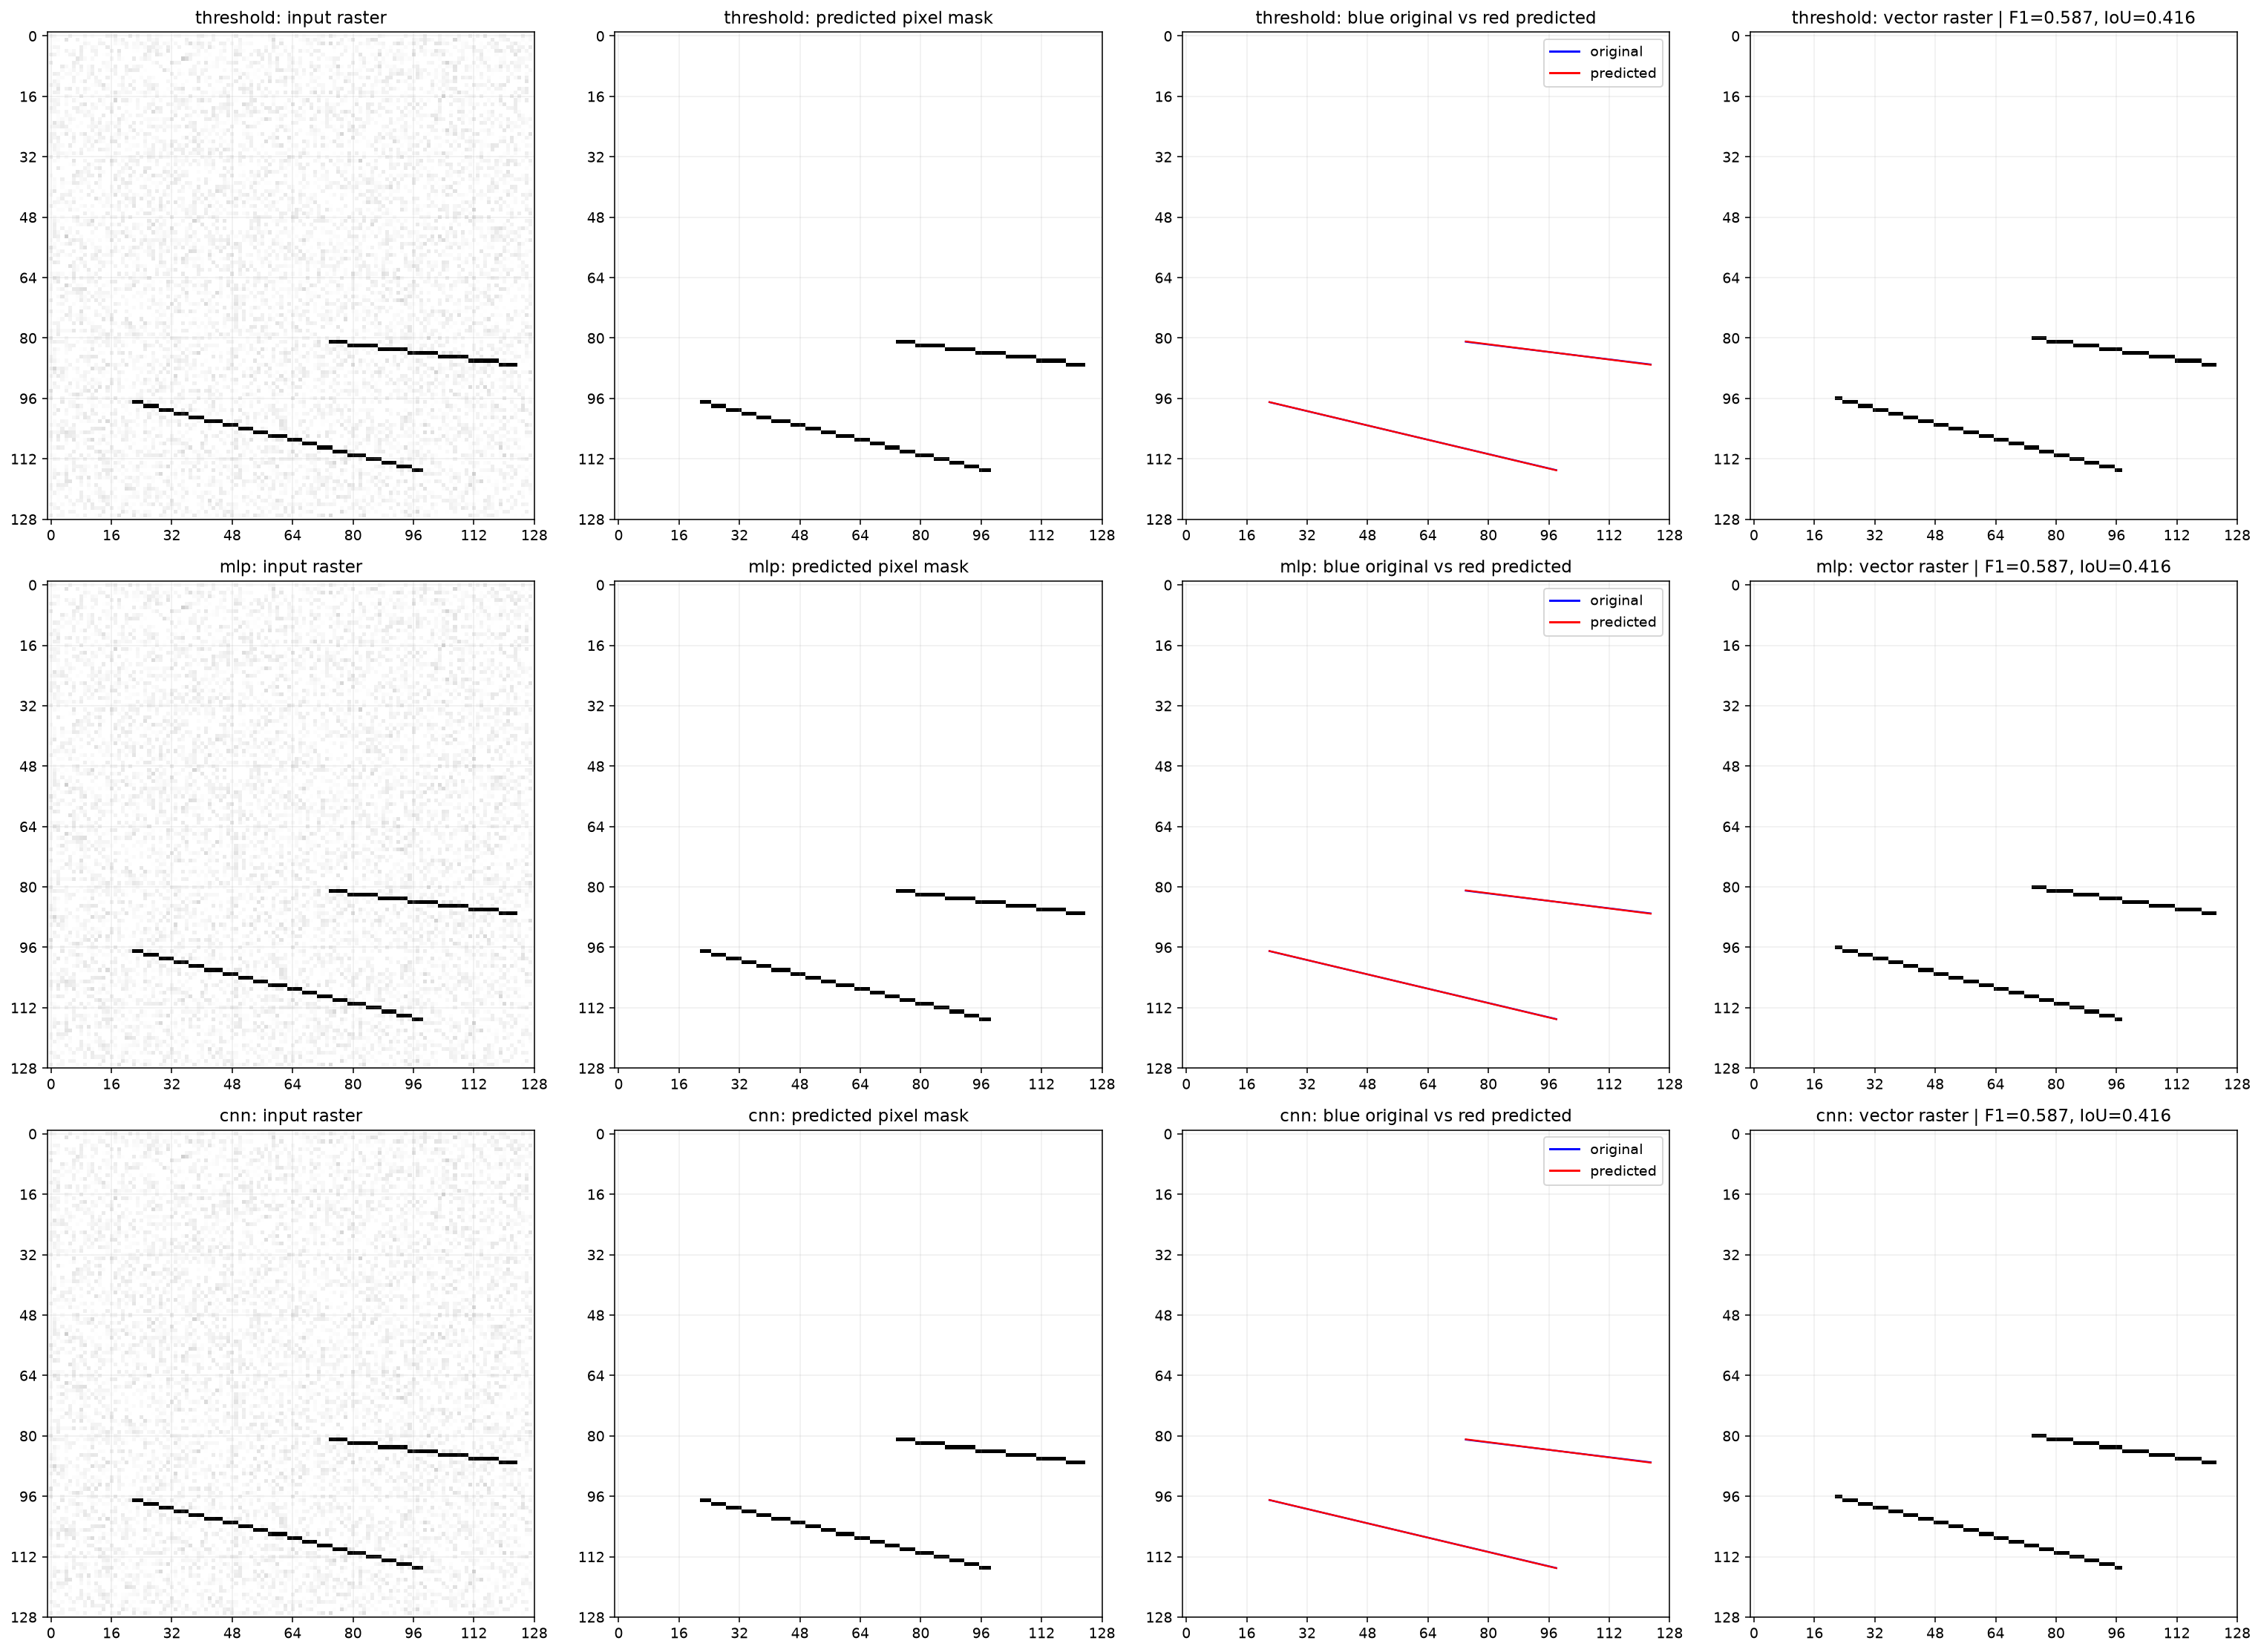

Sample 8


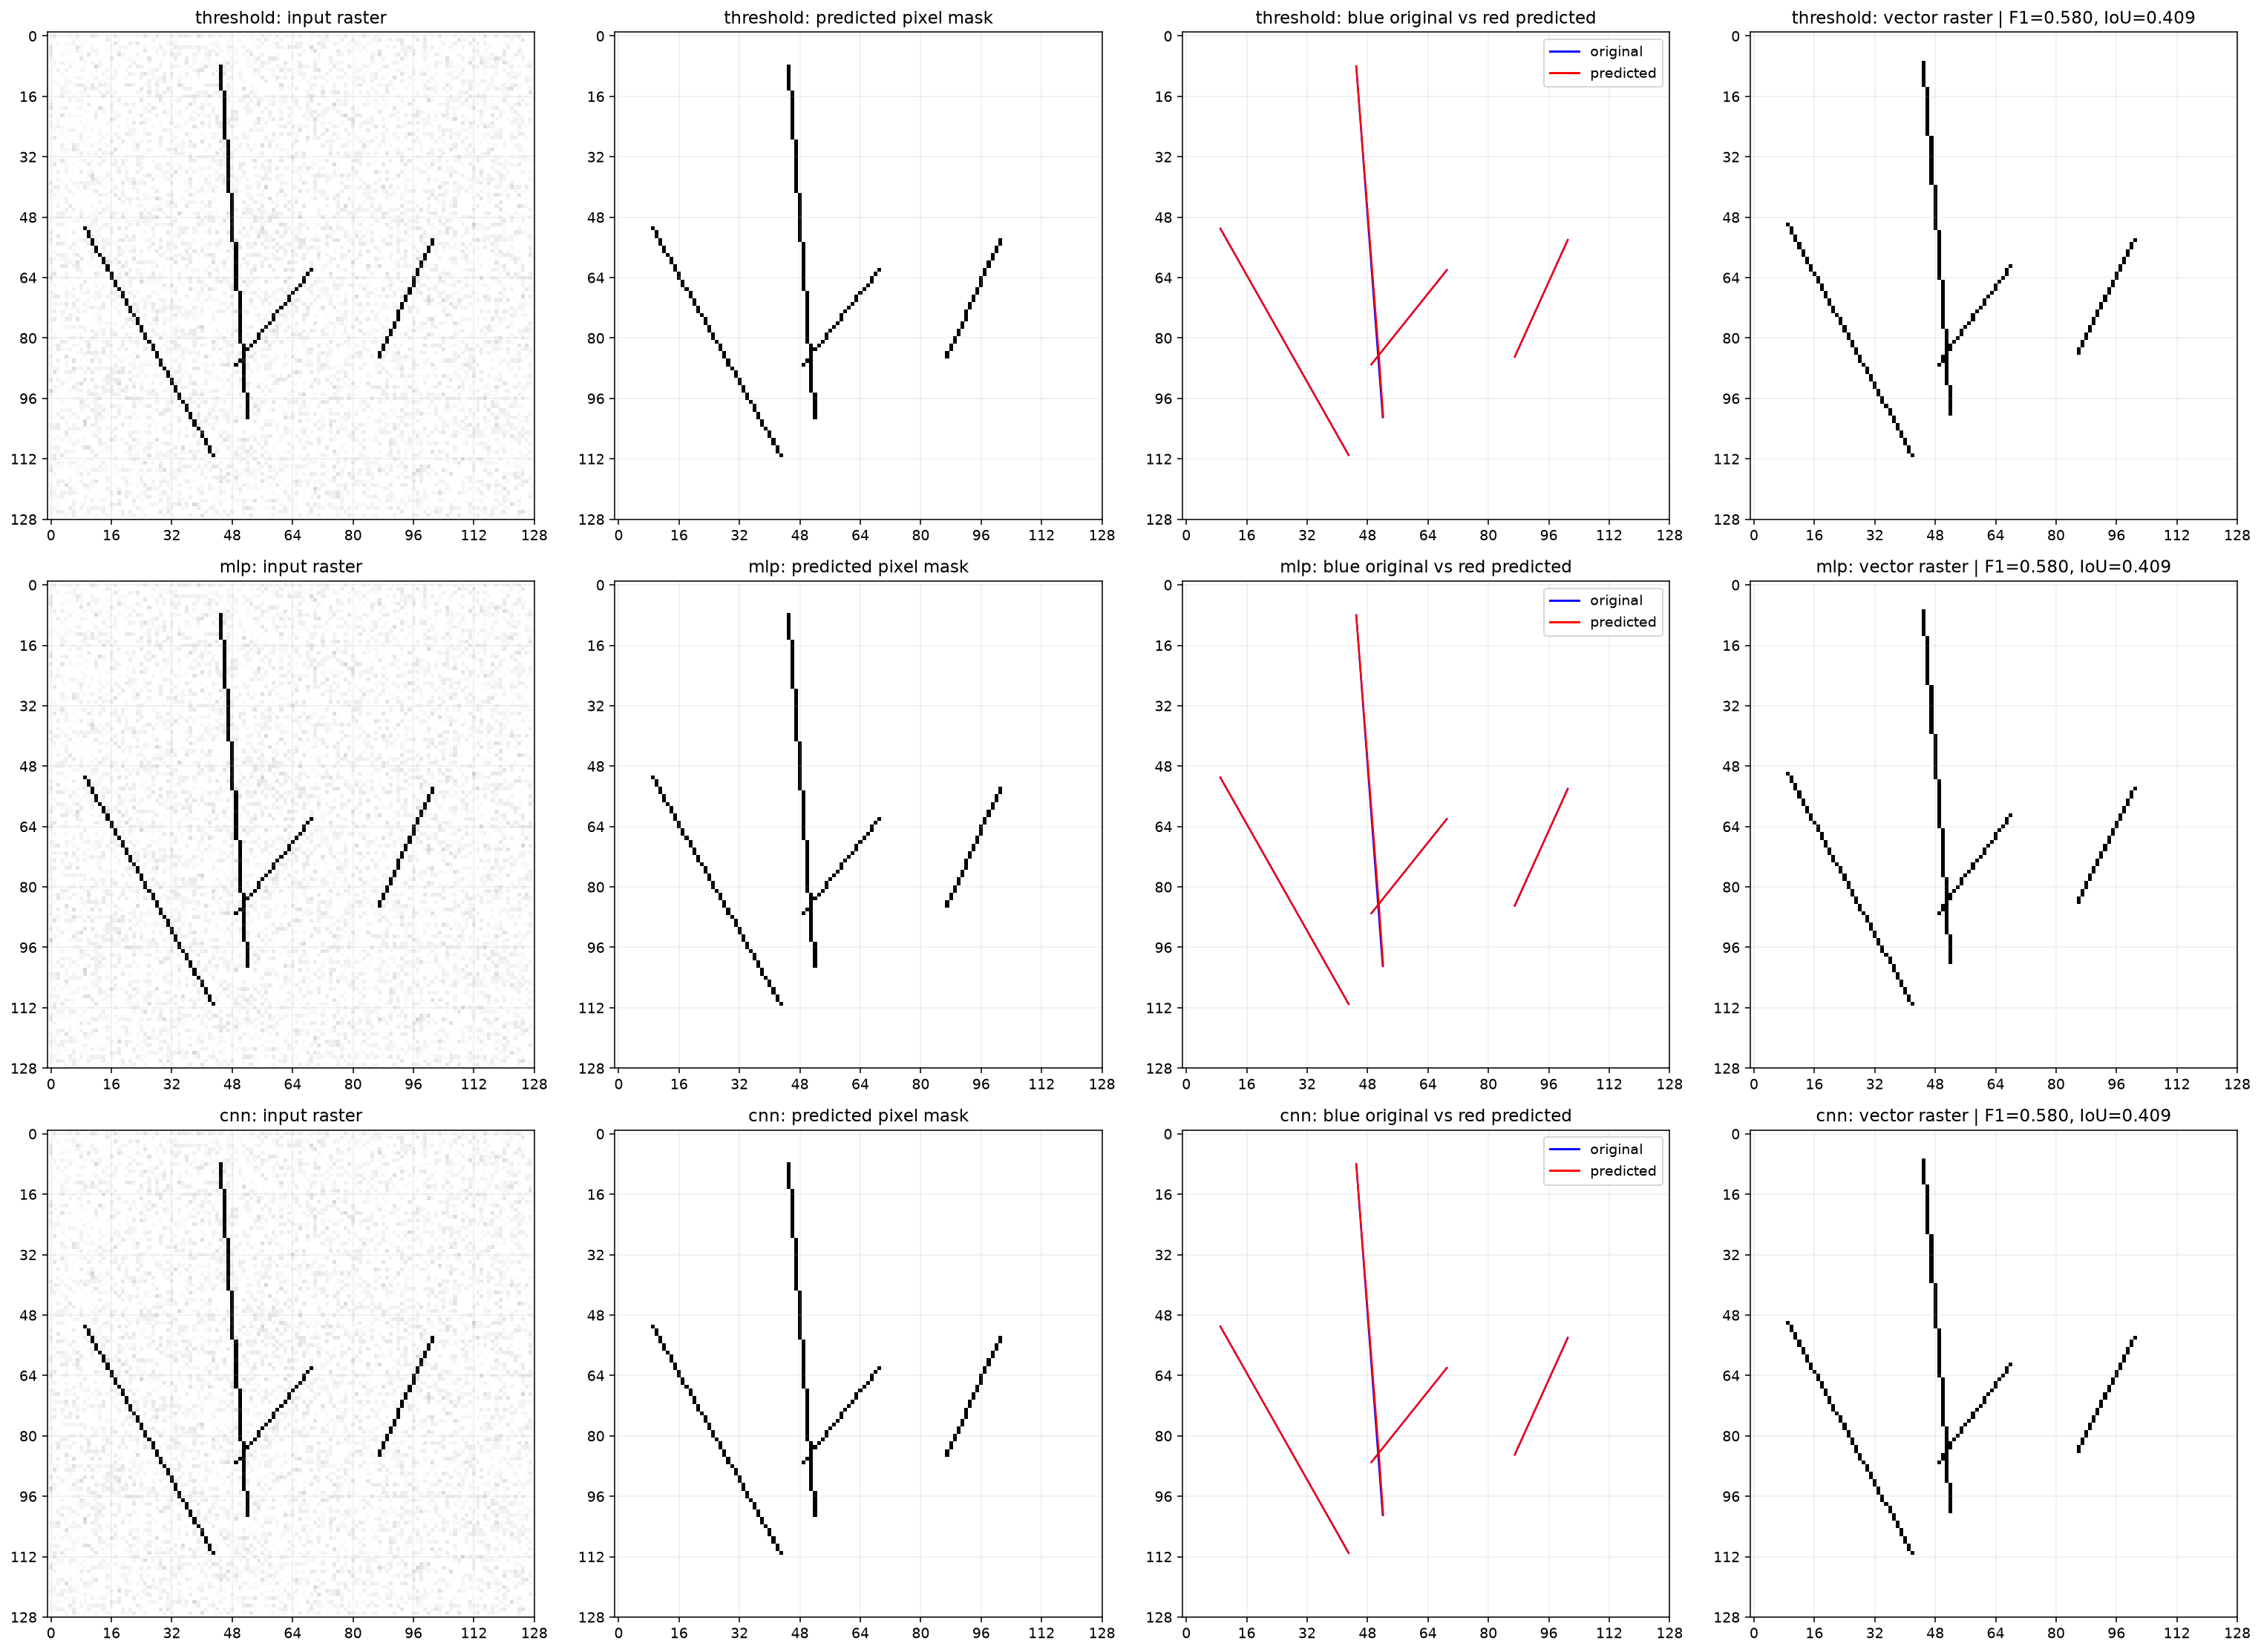

In [18]:

def plot_vectors(ax, lines, color='red', linewidth=1.5, label=None):
    for line in lines:
        ax.plot([line.x1, line.x2], [line.y1, line.y2], color=color, linewidth=linewidth)
    if label:
        ax.plot([], [], color=color, label=label)


def show_classifier_comparison(index):
    raster = test_images[index]
    clean = test_clean[index]
    true = test_vectors[index]
    classifiers = ['threshold', 'mlp', 'cnn']
    results = {c: vectorise_raster_adaptive(raster, classifier=c) for c in classifiers}

    fig, axes = plt.subplots(3, 4, figsize=(22, 16), dpi=140)

    for row, c in enumerate(classifiers):
        result = results[c]
        pred = result['merged_lines']
        pred_raster = raster_from_predicted_lines(pred, img_size=IMG_SIZE)
        m = raster_metrics(clean, pred_raster)

        axes[row, 0].imshow(raster, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
        axes[row, 0].set_title(f'{c}: input raster')

        axes[row, 1].imshow(result['binary'], cmap='gray_r', interpolation='nearest')
        axes[row, 1].set_title(f'{c}: predicted pixel mask')

        axes[row, 2].imshow(np.ones_like(clean), cmap='gray', vmin=0, vmax=1, interpolation='nearest')
        plot_vectors(axes[row, 2], true, color='blue', linewidth=1.2, label='original')
        plot_vectors(axes[row, 2], pred, color='red', linewidth=1.2, label='predicted')
        axes[row, 2].legend(loc='upper right')
        axes[row, 2].set_title(f'{c}: blue original vs red predicted')

        axes[row, 3].imshow(pred_raster, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
        axes[row, 3].set_title(f'{c}: vector raster | F1={m["f1"]:.3f}, IoU={m["iou"]:.3f}')

        for ax in axes[row]:
            ax.set_xlim(-1, IMG_SIZE)
            ax.set_ylim(IMG_SIZE, -1)
            ax.set_aspect('equal')
            ax.set_xticks(np.arange(0, IMG_SIZE + 1, 16))
            ax.set_yticks(np.arange(0, IMG_SIZE + 1, 16))
            ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

random_indices = random.sample(range(N_TEST), 10)
print('Random sample indices:', random_indices)

for idx in random_indices[:2]:
    print('=' * 100)
    print(f'Sample {idx}')
    show_classifier_comparison(idx)


In [19]:
# To inspect all 10 random samples, run this cell manually.
# for idx in random_indices:
#     print('=' * 100)
#     print(f'Sample {idx}')
#     show_classifier_comparison(idx)

## 8. Export random samples as SVG vector layers

In [20]:

EXPORT_DIR = Path('vector_exports_ml_compare')
EXPORT_DIR.mkdir(exist_ok=True)


def export_sample_svg(idx, filename=None):
    image = test_images[idx]
    original_vectors = test_vectors[idx]
    predictions = {c: vectorise_raster_adaptive(image, classifier=c)['merged_lines'] for c in ['threshold', 'mlp', 'cnn']}

    if filename is None:
        filename = EXPORT_DIR / f'sample_{idx}_original_threshold_mlp_cnn.svg'

    scale = 6
    W = IMG_SIZE * scale
    H = IMG_SIZE * scale

    svg = ET.Element('svg', {
        'xmlns': 'http://www.w3.org/2000/svg',
        'width': str(W),
        'height': str(H),
        'viewBox': f'0 0 {IMG_SIZE} {IMG_SIZE}',
    })

    ET.SubElement(svg, 'rect', {
        'x': '0', 'y': '0',
        'width': str(IMG_SIZE),
        'height': str(IMG_SIZE),
        'fill': 'white'
    })

    layer_specs = [
        ('original_vectors', original_vectors, 'blue'),
        ('threshold_vectors', predictions['threshold'], 'red'),
        ('mlp_vectors', predictions['mlp'], 'green'),
        ('cnn_vectors', predictions['cnn'], 'purple'),
    ]

    for layer_id, lines, color in layer_specs:
        layer = ET.SubElement(svg, 'g', {
            'id': layer_id,
            'stroke': color,
            'stroke-width': '1',
            'fill': 'none',
            'stroke-linecap': 'round'
        })
        for line in lines:
            ET.SubElement(layer, 'line', {
                'x1': str(line.x1), 'y1': str(line.y1),
                'x2': str(line.x2), 'y2': str(line.y2)
            })

    tree = ET.ElementTree(svg)
    tree.write(filename, encoding='utf-8', xml_declaration=True)

    print(f'Exported sample {idx}')
    print(f'Original vectors:  {len(original_vectors)}')
    for c in ['threshold', 'mlp', 'cnn']:
        print(f'{c} vectors: {len(predictions[c])}')
    print(f'Saved to: {filename}')
    return filename

exported_files = []
for idx in random_indices[:10]:
    exported_files.append(export_sample_svg(idx))

exported_files


Exported sample 1
Original vectors:  2
threshold vectors: 2
mlp vectors: 2
cnn vectors: 2
Saved to: vector_exports_ml_compare\sample_1_original_threshold_mlp_cnn.svg
Exported sample 8
Original vectors:  4
threshold vectors: 6
mlp vectors: 6
cnn vectors: 6
Saved to: vector_exports_ml_compare\sample_8_original_threshold_mlp_cnn.svg
Exported sample 3
Original vectors:  1
threshold vectors: 1
mlp vectors: 1
cnn vectors: 1
Saved to: vector_exports_ml_compare\sample_3_original_threshold_mlp_cnn.svg
Exported sample 11
Original vectors:  2
threshold vectors: 2
mlp vectors: 2
cnn vectors: 2
Saved to: vector_exports_ml_compare\sample_11_original_threshold_mlp_cnn.svg
Exported sample 14
Original vectors:  3
threshold vectors: 5
mlp vectors: 5
cnn vectors: 5
Saved to: vector_exports_ml_compare\sample_14_original_threshold_mlp_cnn.svg
Exported sample 19
Original vectors:  5
threshold vectors: 5
mlp vectors: 5
cnn vectors: 5
Saved to: vector_exports_ml_compare\sample_19_original_threshold_mlp_cnn.sv

[WindowsPath('vector_exports_ml_compare/sample_1_original_threshold_mlp_cnn.svg'),
 WindowsPath('vector_exports_ml_compare/sample_8_original_threshold_mlp_cnn.svg'),
 WindowsPath('vector_exports_ml_compare/sample_3_original_threshold_mlp_cnn.svg'),
 WindowsPath('vector_exports_ml_compare/sample_11_original_threshold_mlp_cnn.svg'),
 WindowsPath('vector_exports_ml_compare/sample_14_original_threshold_mlp_cnn.svg'),
 WindowsPath('vector_exports_ml_compare/sample_19_original_threshold_mlp_cnn.svg'),
 WindowsPath('vector_exports_ml_compare/sample_16_original_threshold_mlp_cnn.svg'),
 WindowsPath('vector_exports_ml_compare/sample_5_original_threshold_mlp_cnn.svg'),
 WindowsPath('vector_exports_ml_compare/sample_12_original_threshold_mlp_cnn.svg'),
 WindowsPath('vector_exports_ml_compare/sample_15_original_threshold_mlp_cnn.svg')]

## Notes

- The **threshold** method is still expected to be strong on clean black/white images.
- The **MLP** uses a 5×5 local patch around each pixel.
- The **CNN** sees spatial context across the full image and may be more robust when noise or greyscale variation is present.
- The reconstruction stage is unchanged in purpose: it converts pixel-level masks into explicit vector line segments.